In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr


<frozen importlib._bootstrap>:219: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject


# Correlation


In [2]:
df = pd.read_csv("../supp_fig1/sample_metadata.csv")
df = df[df['Experiment'].isin(['igvf_003', 'igvf_004', 
                              'igvf_005', 'igvf_007', 
                              'igvf_008', 'igvf_008b', 
                              'igvf_009', 'igvf_010', 
                              'igvf_011', 'igvf_012'])]

df = df[['Mouse_Tissue_ID', 'Genotype', 'Tissue', 'Sex', 'Body_weight_g', 'Tissue_weight_mg']]


df = df.drop_duplicates()

df['Tissue'].replace('HypothalamusPituitary', 'Diencephalon/Pituitary', inplace=True)
df['Tissue'].replace('CortexHippocampus', 'Cortex/Hippocampus', inplace=True)
df['Tissue'].replace('Adrenal', 'Adrenal gland', inplace=True)
df['Tissue'].replace('GonadsMale', 'Testes/Epididymis', inplace=True)
df['Tissue'].replace('GonadsFemale', 'Ovary/Oviduct', inplace=True)
df['Body_weight_g'] = pd.to_numeric(df['Body_weight_g'])
df['Tissue_weight_mg'] = pd.to_numeric(df['Tissue_weight_mg'])

# Drop rows with NaN values
df.dropna(subset=['Body_weight_g', 'Tissue_weight_mg'], inplace=True)

df['Mouse_ID'] = df['Mouse_Tissue_ID'].str.split('_').str[0]




# Define genotype palette
geno_palette = {
    '129S1J': '#DA9CC1',
    'AJ': '#F4C245',
    'B6J': '#C0BFBF',
    'CASTJ': '#55AF5B',
    'NODJ': '#4F6EAF',
    'NZOJ': '#52A5DB',
    'PWKJ': '#D83026',
    'WSBJ': '#683C91'
}

# Assuming your DataFrame is named df
# Convert 'Body_weight_g' and 'Tissue_weight_mg' columns to numeric
df['Body_weight_g'] = pd.to_numeric(df['Body_weight_g'])
df['Tissue_weight_mg'] = pd.to_numeric(df['Tissue_weight_mg'])

# Drop rows with NaN values
df.dropna(subset=['Body_weight_g', 'Tissue_weight_mg'], inplace=True)

# Get unique tissue types
unique_tissues = df['Tissue'].unique()

# Set up the plot
sns.set(style="whitegrid", font_scale=1.6)



Cortex/Hippocampus


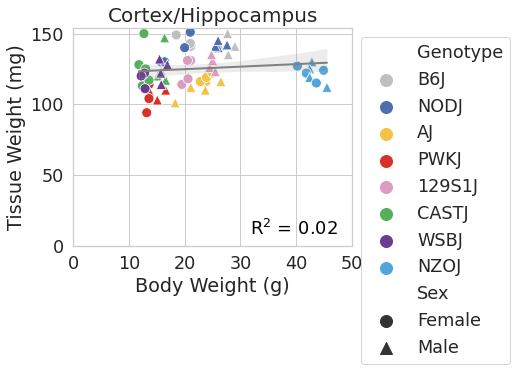

Heart


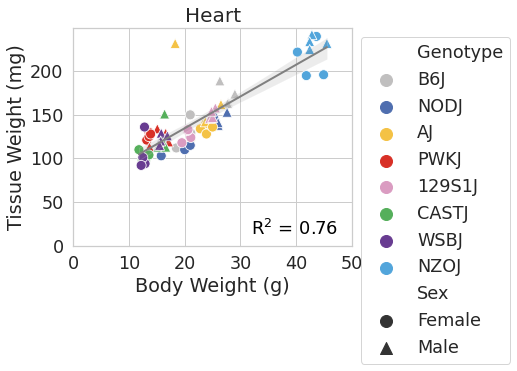

Liver


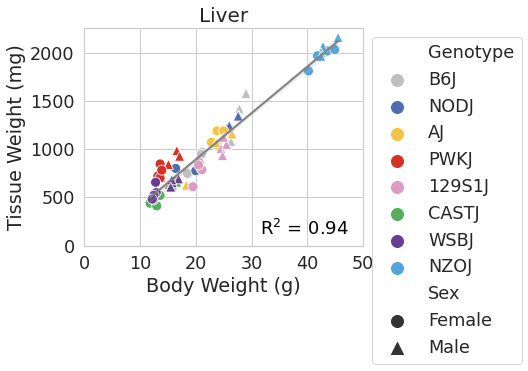

DiencephalonPituitary


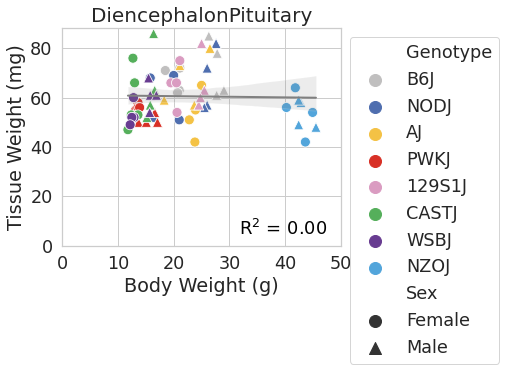

Ovary/Oviduct


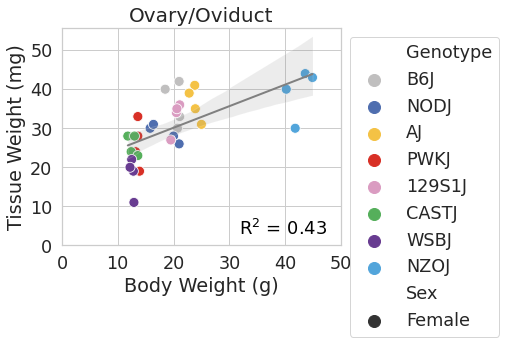

Testes/Epididymis


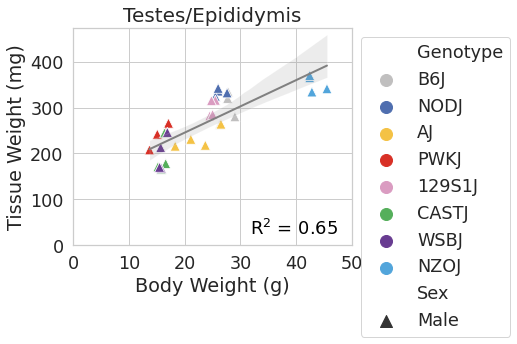

Adrenal gland


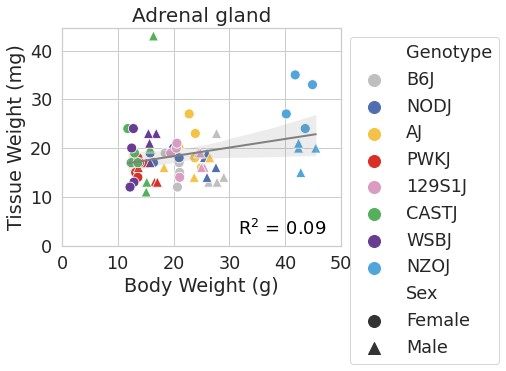

Kidney


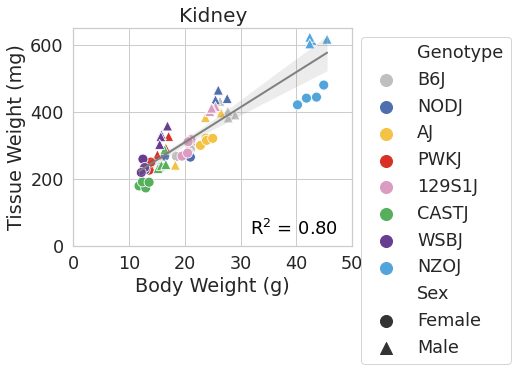

Gastrocnemius


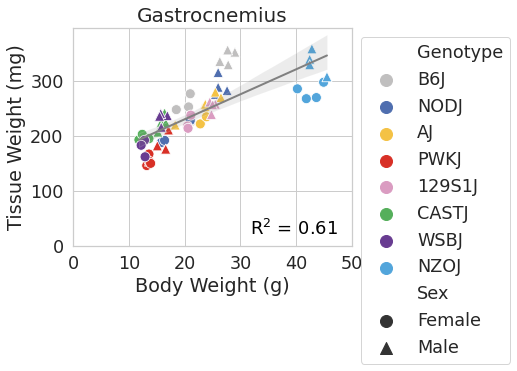

{'Cortex/Hippocampus': 0.015752970256929948, 'Heart': 0.7558675575344329, 'Liver': 0.9412853887460159, 'DiencephalonPituitary': 0.0005098787807414009, 'Ovary/Oviduct': 0.42938789360132595, 'Testes/Epididymis': 0.6531458865228942, 'Adrenal gland': 0.08630925690992913, 'Kidney': 0.7997642009793445, 'Gastrocnemius': 0.6107022406871243}


In [4]:
r_squared_values = {}

for tissue in unique_tissues:
    plt.figure(figsize=(5, 4))
    tissue_df = df[df['Tissue'] == tissue]
    print(tissue)
    
    # Define marker styles
    marker_style = (
        'o' if tissue == 'Ovary/Oviduct' else
        '^' if tissue == 'Testes/Epididymis' else
        {'Male': '^', 'Female': 'o'}
    )
    
    # Scatter plot with genotype coloring and sex style
    sns.scatterplot(
        data=tissue_df, x='Body_weight_g', y='Tissue_weight_mg',
        hue='Genotype', style='Sex',
        palette=geno_palette, markers=marker_style, s=100
    )
    
    # Overlay regression line + shaded CI (no scatter points)
    sns.regplot(
        data=tissue_df, x='Body_weight_g', y='Tissue_weight_mg',
        scatter=False, ci=95,
        line_kws={'color': 'grey', 'linewidth': 2}
    )
    
    # Pearson correlation R^2
    if len(tissue_df) > 1:  # need at least 2 points
        r, _ = pearsonr(tissue_df['Body_weight_g'], tissue_df['Tissue_weight_mg'])
        r_squared = r**2
    else:
        r_squared = np.nan
    r_squared_values[tissue] = r_squared
    
    # Set x and y limits
    plt.xlim(0, 50)
    plt.ylim(0, None)
    
    # Add legend outside the plot
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1), markerscale=2)
    
    # Add labels and title
    plt.xlabel('Body Weight (g)')
    plt.ylabel('Tissue Weight (mg)')
    plt.title(f'{tissue}', fontsize=20)
    
    # Annotate plot with Pearson R^2 value
    plt.text(0.95, 0.05, f'R$^2$ = {r_squared:.2f}',
             transform=plt.gca().transAxes,
             ha='right', fontsize=18, color='black')
    
    # Save plot as PDF
    plt.savefig(f'../supp_fig1/{tissue.replace("/", "").replace(" ", "")}_weight_scatter.pdf',
               bbox_inches='tight')
    
    plt.show()

print(r_squared_values)
